## ASHRAE Energy Consumption Forecasting

This notebook develops a time-series forecasting model for electricity consumption of a selected building from the ASHRAE dataset.

Import the required libraries and load the training data. The timestamp column is converted to pandas datetime so that its time components can be inspected.

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

train = pd.read_csv("../data/train.csv")
train["timestamp"] = pd.to_datetime(train["timestamp"])

The timestamps are checked to confirm the available hourly observations, followed by a basic overview of the dataset.

In [3]:
train.head(10)

,building_id,meter,timestamp,meter_reading
0,0,0,2016-01-01,0.0
1,1,0,2016-01-01,0.0
2,2,0,2016-01-01,0.0
3,3,0,2016-01-01,0.0
4,4,0,2016-01-01,0.0
5,5,0,2016-01-01,0.0
6,6,0,2016-01-01,0.0
7,7,0,2016-01-01,0.0
8,8,0,2016-01-01,0.0
9,9,0,2016-01-01,0.0


In [4]:
train["timestamp"].dt.hour.unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23], dtype=int32)

In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 20216100 entries, 0 to 20216099
Data columns (total 4 columns):
 #   Column         Dtype         
---  ------         -----         
 0   building_id    int64         
 1   meter          int64         
 2   timestamp      datetime64[us]
 3   meter_reading  float64       
dtypes: datetime64[us](1), float64(1), int64(2)
memory usage: 616.9 MB


The analysis is restricted to `meter = 0`.

In [6]:
train["meter"].value_counts()

train = train[train["meter"] == 0].reset_index(drop=True)
train.head()

,building_id,meter,timestamp,meter_reading
0,0,0,2016-01-01,0.0
1,1,0,2016-01-01,0.0
2,2,0,2016-01-01,0.0
3,3,0,2016-01-01,0.0
4,4,0,2016-01-01,0.0


In [7]:
train.describe()

,building_id,meter,timestamp,meter_reading
count,1.206091e+07,12060910.0,12060910,1.206091e+07
mean,7.066480e+02,0.0,2016-07-03 03:44:58.224462,1.708256e+02
min,0.000000e+00,0.0,2016-01-01 00:00:00,0.000000e+00
25%,3.450000e+02,0.0,2016-04-04 07:00:00,1.950000e+01
50%,6.980000e+02,0.0,2016-07-03 16:00:00,6.283190e+01
75%,1.063000e+03,0.0,2016-10-02 08:00:00,1.700750e+02
max,1.448000e+03,0.0,2016-12-31 23:00:00,7.976900e+04
std,4.152330e+02,0.0,NaN,3.808343e+02


In [8]:
train.shape

(12060910, 4)

A complete year of hourly observations contains `8,784` readings. Buildings are grouped by the number of available readings and sorted from most complete to least complete.

In [9]:
counts = train.groupby("building_id").size().sort_values(ascending=False)
counts.head(1200)

building_id
1324    8784
1323    8784
31      8784
30      8784
28      8784
        ... 
817     8447
864     8447
836     8447
999     8446
296     8438
Length: 1200, dtype: int64

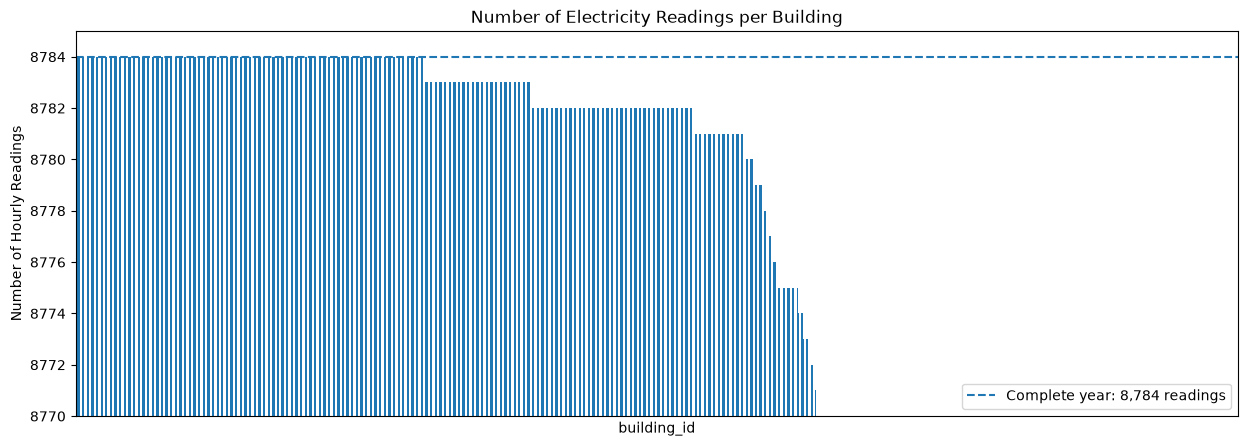

In [10]:
plt.figure(figsize=(15, 5))
counts.plot(kind="bar")
plt.title("Number of Electricity Readings per Building")
plt.ylabel("Number of Hourly Readings")
plt.ylim(8770, 8785)
plt.xticks([])
plt.axhline(8784, linestyle="--", label="Complete year: 8,784 readings")
plt.legend()
plt.show()

In [11]:
complete_count = (counts == 8784).sum()
near_complete_count = (counts >= 8784 * 0.95).sum()

print("Buildings with complete data:", complete_count)
print("Buildings with at least 95% of a full year:", near_complete_count)

Buildings with complete data: 423
Buildings with at least 95% of a full year: 1221


In [12]:
counts.describe()

count    1413.000000
mean     8535.675867
std       757.520255
min       479.000000
25%      8758.000000
50%      8782.000000
75%      8784.000000
max      8784.000000
dtype: float64

Only buildings with exactly `8,784` readings are retained for the next stage of analysis.

In [13]:
complete_buildings = counts[counts == 8784].index
train = train[train["building_id"].isin(complete_buildings)].reset_index(drop=True)

train.describe()

,building_id,meter,timestamp,meter_reading
count,3.715632e+06,3715632.0,3715632,3.715632e+06
mean,6.985343e+02,0.0,2016-07-01 23:29:59.999999,1.569519e+02
min,0.000000e+00,0.0,2016-01-01 00:00:00,0.000000e+00
25%,1.130000e+02,0.0,2016-04-01 11:45:00,1.200000e+01
50%,7.180000e+02,0.0,2016-07-01 23:30:00,5.500000e+01
75%,1.184000e+03,0.0,2016-10-01 11:15:00,1.735890e+02
max,1.324000e+03,0.0,2016-12-31 23:00:00,5.654510e+03
std,4.966161e+02,0.0,NaN,2.790747e+02


The data is pivoted so that each building becomes a column and each timestamp becomes a row. This makes it easier to compare readings across buildings.

In [14]:
building_df = train.pivot(
    index="timestamp",
    columns="building_id",
    values="meter_reading"
)

building_df.head()

building_id,0,1,2,3,4,5,6,7,8,9,...,1313,1314,1315,1316,1317,1319,1320,1321,1323,1324
timestamp,,,,,,,,,,,,,,,,,,,,,
2016-01-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,235.53,401.339,35.76,41.2187,373.938,119.9970,89.8141,342.0,177.0,109.0
2016-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,272.71,401.339,34.02,42.2500,373.688,107.9950,89.8240,321.0,180.0,108.0
2016-01-01 02:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,251.74,401.339,32.52,41.1250,372.875,83.9955,81.4715,302.0,177.0,108.0
2016-01-01 03:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,279.55,401.339,32.52,40.4375,372.062,107.9950,107.1200,310.0,167.0,108.0
2016-01-01 04:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,236.37,401.339,32.52,43.0938,368.375,95.9952,70.3711,304.0,138.0,109.0


For each building, calculate the number and percentage of readings equal to zero. Lower zero percentages indicate buildings with fewer zero-valued readings.

In [15]:
zero_counts = (building_df == 0).sum()
zero_percentage = (zero_counts / len(building_df)) * 100

zero_stats = pd.DataFrame({
    "zero_count": zero_counts,
    "zero_percentage": zero_percentage
})

zero_stats = zero_stats.sort_values("zero_percentage")
zero_stats

,zero_count,zero_percentage
building_id,,
1220,0,0.000000
1199,0,0.000000
1198,0,0.000000
1197,0,0.000000
1196,0,0.000000
...,...,...
71,3389,38.581512
69,3627,41.290984
1113,5003,56.955829


The final subset contains buildings whose electricity readings never equal zero in the available data.

In [16]:
building_df_best = building_df.loc[:, zero_stats["zero_percentage"] == 0]
building_df_best.describe()

building_id,105,107,108,109,110,111,112,113,114,115,...,1196,1197,1198,1199,1201,1205,1211,1216,1217,1220
count,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.00000,8784.000000,...,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000
mean,78.124031,234.756755,239.155932,255.898231,308.810897,411.954649,26.094731,363.974478,871.00805,490.377471,...,84.732733,228.280665,61.591920,20.287064,87.498162,55.609460,60.879899,23.355676,89.906097,543.478606
std,27.533489,179.950163,51.346955,61.743618,42.148267,65.272680,34.716359,39.459633,142.61732,59.447651,...,25.266562,65.760280,19.588697,3.081857,74.826754,42.930892,29.375965,7.289218,25.947475,355.541173
min,23.303600,0.040500,81.806400,80.930000,86.228300,167.392000,0.007000,159.643000,324.75000,201.543000,...,23.239500,108.663000,13.478000,8.617000,6.864000,13.490000,18.222000,6.968500,28.490500,71.401500
25%,56.299725,60.000000,206.500000,213.101500,295.625000,364.421500,0.007000,334.750000,761.75000,451.375000,...,62.352500,204.749250,46.631750,18.428750,25.525750,23.381750,35.566000,17.870000,66.170750,262.960000
50%,75.115100,323.000000,231.355000,239.328000,310.469000,404.500000,20.253700,359.750000,833.53100,476.329000,...,89.313500,215.943500,59.587500,20.279000,57.435000,31.923000,48.556500,21.652000,86.620500,473.422500
75%,86.464750,388.152000,261.000000,295.173750,338.605000,429.625000,30.598700,377.250000,936.81250,509.830000,...,103.615250,253.838000,75.637000,22.182250,138.868000,85.417500,85.900500,29.191750,113.595500,678.803000
max,173.945000,591.000000,451.500000,553.508000,588.000000,680.250000,174.125000,679.250000,1482.19000,711.375000,...,145.639000,653.661000,123.437000,32.161000,311.129000,189.718000,141.458000,44.405000,158.113000,2402.690000


Building 105 is filtered directly from the `train` already in memory (already narrowed to `meter == 0` and to buildings with a complete 8,784-reading year). Building 105's individual rows are unaffected by which other buildings passed the completeness/zero-reading screen, so this is exactly equivalent to the old re-read-and-refilter approach, just without hitting the disk twice more.

In [17]:
train = train[train['building_id'] == 105].drop(columns=['meter', 'building_id']).reset_index(drop=True)
train.head()

,timestamp,meter_reading
0,2016-01-01 00:00:00,23.3036
1,2016-01-01 01:00:00,45.6071
2,2016-01-01 02:00:00,45.6071
3,2016-01-01 03:00:00,45.1071
4,2016-01-01 04:00:00,45.6071


In [18]:
train.describe()

,timestamp,meter_reading
count,8784,8784.000000
mean,2016-07-01 23:30:00,78.124031
min,2016-01-01 00:00:00,23.303600
25%,2016-04-01 11:45:00,56.299725
50%,2016-07-01 23:30:00,75.115100
75%,2016-10-01 11:15:00,86.464750
max,2016-12-31 23:00:00,173.945000
std,NaN,27.533489


In [19]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   timestamp      8784 non-null   datetime64[us]
 1   meter_reading  8784 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 137.4 KB


hour-of-day average, extract hour from timestamp and average across all days.

<Axes: xlabel='hour'>

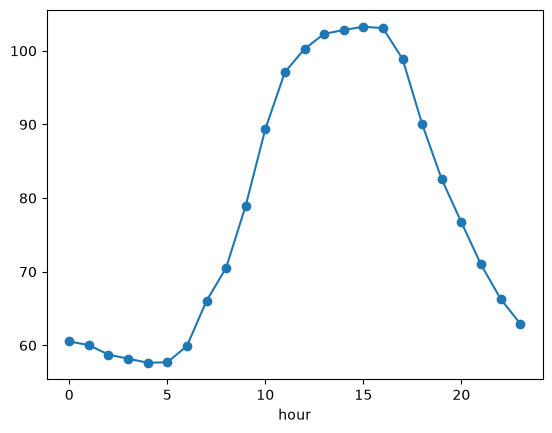

In [20]:
train['hour'] = train['timestamp'].dt.hour
plt.grid()
train.groupby('hour')['meter_reading'].mean().plot(kind='line', marker='o')

clear daily cycle. flat and low overnight (~58 kWh between 2-5am), starts climbing at 6am, peaks 12pm-4pm (~100-103 kWh), tapers off through the evening. makes sense for an occupancy-driven load - lighting, HVAC, classroom/lab equipment ramping up with the school day.

day-of-week average (0=Mon...6=Sun).

<Axes: xlabel='dow'>

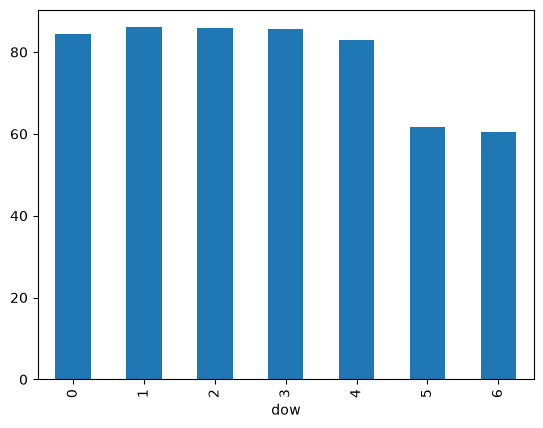

In [21]:
train['dow'] = train['timestamp'].dt.dayofweek  # 0=Mon
train.groupby('dow')['meter_reading'].mean().plot(kind='bar')

weekdays average ~83-86 kWh, weekends drop to ~61-62 kWh, about 28% lower. drop is real but not extreme - some baseload (HVAC setback, servers, security) keeps running even when building isn't active.

top 10 highest readings of the year

In [22]:
train.sort_values('meter_reading', ascending=False).head(10)

,timestamp,meter_reading,hour,dow
8005,2016-11-29 13:00:00,173.945,13,1
8006,2016-11-29 14:00:00,172.031,14,1
8008,2016-11-29 16:00:00,171.601,16,1
8007,2016-11-29 15:00:00,171.351,15,1
8004,2016-11-29 12:00:00,169.664,12,1
7982,2016-11-28 14:00:00,168.969,14,0
8003,2016-11-29 11:00:00,168.141,11,1
7813,2016-11-21 13:00:00,168.047,13,0
7981,2016-11-28 13:00:00,167.797,13,0
7980,2016-11-28 12:00:00,165.453,12,0


6 of the top 10 are all from the same Nov 28-29 window

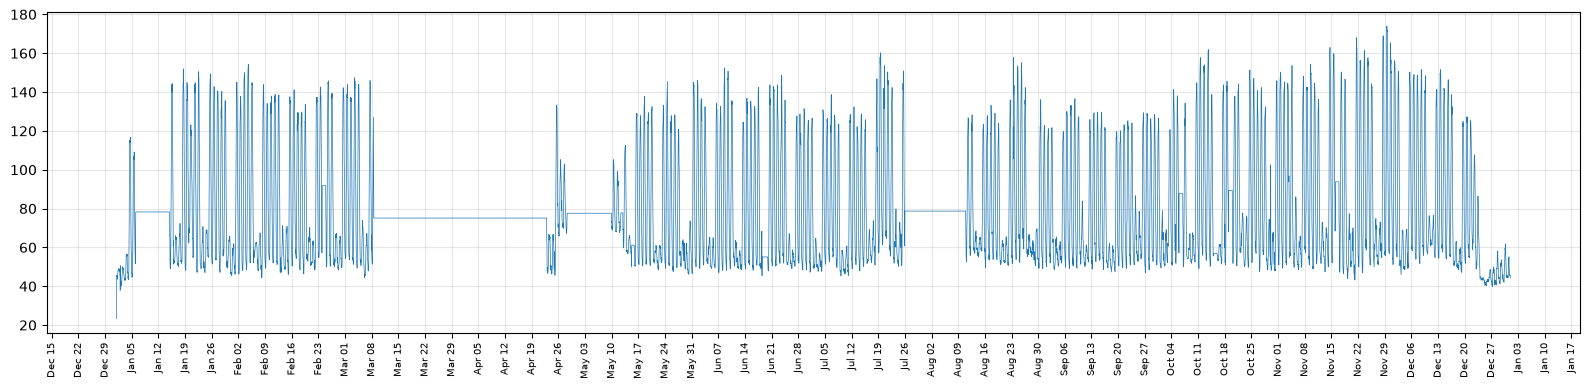

In [23]:
fig, ax = plt.subplots(figsize=(16,4))
ax.plot(train['timestamp'], train['meter_reading'], linewidth=0.5)
ax.xaxis.set_major_locator(plt.matplotlib.dates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %d'))
plt.xticks(rotation=90, fontsize=7)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### hour x weekday heatmap
combining the daily and weekly views into one picture

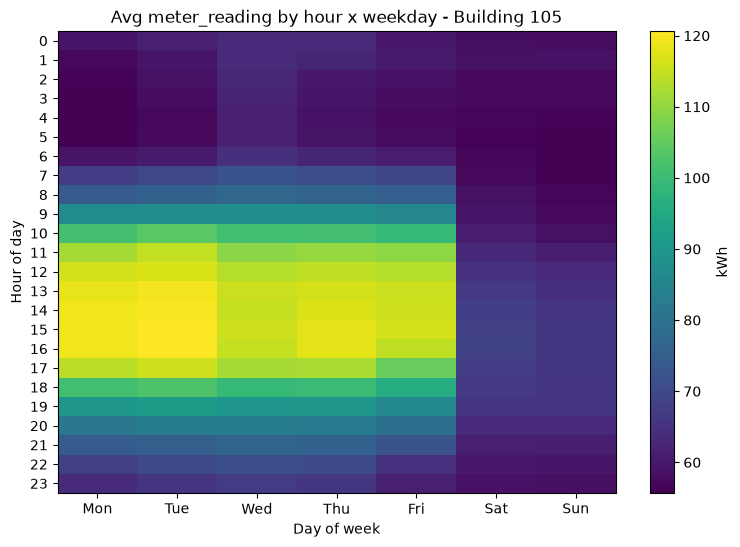

In [24]:
pivot = train.pivot_table(index='hour', columns='dow', values='meter_reading', aggfunc='mean')
pivot.columns = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

fig, ax = plt.subplots(figsize=(9,6))
im = ax.imshow(pivot, aspect='auto', cmap='viridis')
ax.set_yticks(range(24)); ax.set_yticklabels(pivot.index)
ax.set_xticks(range(7)); ax.set_xticklabels(pivot.columns)
ax.set_xlabel('Day of week'); ax.set_ylabel('Hour of day')
ax.set_title('Avg meter_reading by hour x weekday - Building 105')
plt.colorbar(im, label='kWh')
plt.show()

### weekday vs weekend load profile
same info as the heatmap, just easier to read exact numbers off.

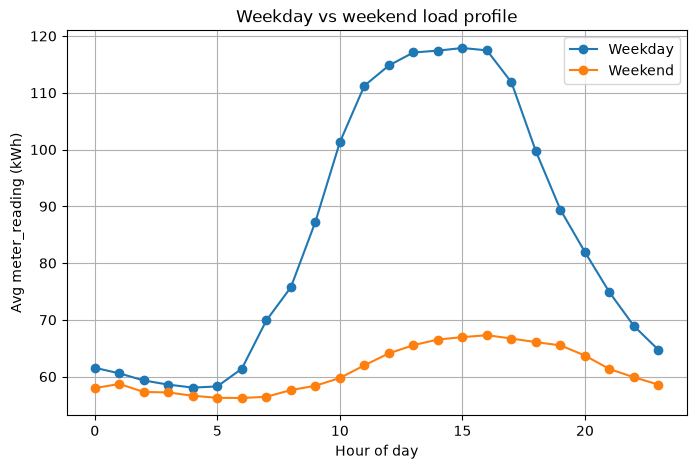

In [25]:
train['is_weekend'] = train['dow'] >= 5

fig, ax = plt.subplots(figsize=(8,5))
for is_we, grp in train.groupby('is_weekend'):
    label = 'Weekend' if is_we else 'Weekday'
    grp.groupby('hour')['meter_reading'].mean().plot(ax=ax, marker='o', label=label)
ax.set_xlabel('Hour of day'); ax.set_ylabel('Avg meter_reading (kWh)')
ax.set_title('Weekday vs weekend load profile')
ax.legend(); ax.grid()
plt.show()

### distribution shape

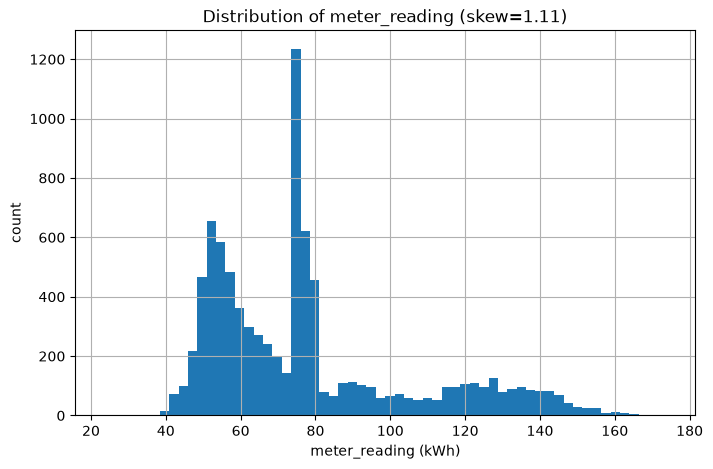

In [26]:
fig, ax = plt.subplots(figsize=(8,5))
train['meter_reading'].hist(bins=60, ax=ax)
ax.set_xlabel('meter_reading (kWh)'); ax.set_ylabel('count')
ax.set_title(f"Distribution of meter_reading (skew={train['meter_reading'].skew():.2f})")
plt.show()

few clusters here instead of one smooth peak - low ~45-60 kWh (nights/weekends), a spike right at 75 (the flat/bad data stretch), and spread 90-160 (occupied daytime).

### autocorrelation (ACF)

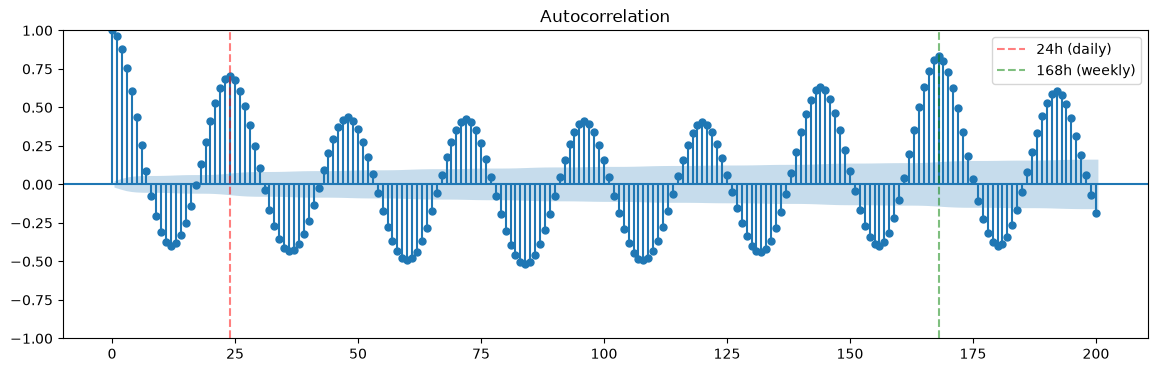

In [27]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(14,4))
plot_acf(train.set_index('timestamp')['meter_reading'], lags=200, ax=ax)
ax.axvline(24, color='red', linestyle='--', alpha=0.5, label='24h (daily)')
ax.axvline(168, color='green', linestyle='--', alpha=0.5, label='168h (weekly)')
ax.legend()
plt.show()

clear peaks at every 24-hour lag (correlation ~0.4-0.7), confirms the daily cycle is strong all year
lag-168 (1 week) peak is noticeably taller (~0.7) than the daily peaks around it (~0.4) - meaning same hour same day-of-week last week predicts today better than a random day last week does

dropping the dead-flat march-late april stretch before merging weather in.

In [28]:
bad_start, bad_end = '2016-03-01', '2016-04-20'
train = train[~train['timestamp'].between(bad_start, bad_end)].reset_index(drop=True)
train.shape

(7583, 5)

site 1 is building 105's site, loading its weather and merging on timestamp.

In [29]:
weather = pd.read_csv('../data/weather_train.csv')
weather = weather[weather['site_id'] == 1].drop(columns=['site_id'])
weather['timestamp'] = pd.to_datetime(weather['timestamp'])
weather.isna().sum()

timestamp                0
air_temperature          1
cloud_coverage        7062
dew_temperature          1
precip_depth_1_hr     8763
sea_level_pressure      52
wind_direction           3
wind_speed               0
dtype: int64

cloud_coverage and precip_depth_1_hr are almost entirely missing for this site (7062 and 8763 nulls out of 8763 rows) so they're not usable - dropping them. air_temperature, dew_temperature, sea_level_pressure, wind_direction, wind_speed are basically complete, keeping those.

a handful of weather timestamps are missing entirely from the source file (not just null values within an existing row) - a plain `ffill()` only fills gaps in rows that already exist, so it silently missed these. reindexing to the full hourly range first catches them too, before forward-filling.

In [30]:
weather = weather.drop(columns=['cloud_coverage', 'precip_depth_1_hr'])
weather = weather.set_index('timestamp').reindex(
    pd.date_range('2016-01-01', '2016-12-31 23:00', freq='h')
).rename_axis('timestamp').reset_index().ffill()

df = train.merge(weather, on='timestamp', how='left')
df.isna().sum()

timestamp             0
meter_reading         0
hour                  0
dow                   0
is_weekend            0
air_temperature       0
dew_temperature       0
sea_level_pressure    0
wind_direction        0
wind_speed            0
dtype: int64

### temperature vs consumption
scatter of air_temperature against meter_reading, plus the correlation number.

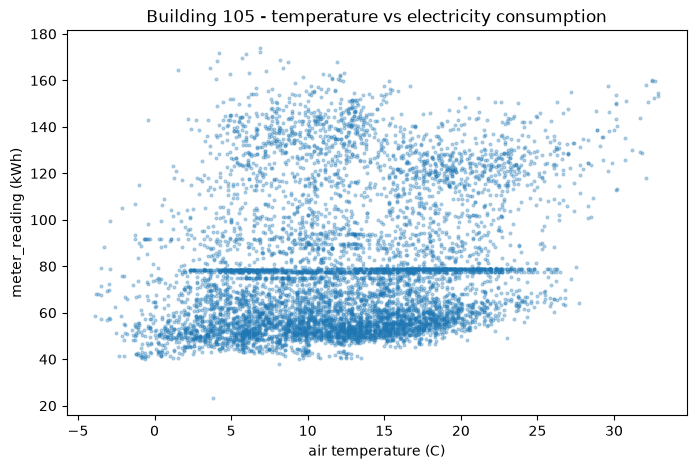

correlation: 0.21902314520595548


In [31]:
fig, ax = plt.subplots(figsize=(8,5))
ax.scatter(df['air_temperature'], df['meter_reading'], s=4, alpha=0.3)
ax.set_xlabel('air temperature (C)')
ax.set_ylabel('meter_reading (kWh)')
ax.set_title('Building 105 - temperature vs electricity consumption')
plt.show()

print('correlation:', df['air_temperature'].corr(df['meter_reading']))

The relationship is mixed, with multiple clouds suggesting occupancy or operating hours may be affecting consumption

### temperature vs consumption, split by occupied hours
splitting into occupied (10am-5pm weekdays, where step 2 showed the real load swings) vs the rest, since lumping night/weekend readings in with daytime ones muddies the temperature relationship. `hour`/`dow` are already on `df` from the merge (train already had them) - no need to recompute.

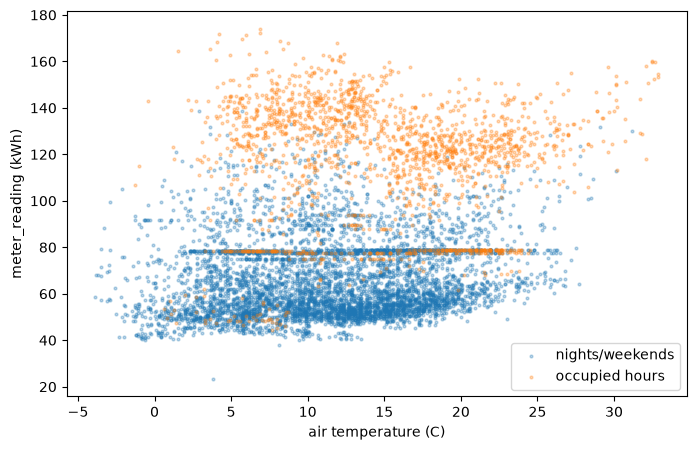

unoccupied correlation: 0.135
occupied correlation: 0.001


In [32]:
df['occupied'] = df['hour'].between(10, 17) & (df['dow'] < 5)

fig, ax = plt.subplots(figsize=(8,5))
for occ, grp in df.groupby('occupied'):
    label = 'occupied hours' if occ else 'nights/weekends'
    ax.scatter(grp['air_temperature'], grp['meter_reading'], s=4, alpha=0.3, label=label)
ax.set_xlabel('air temperature (C)'); ax.set_ylabel('meter_reading (kWh)')
ax.legend()
plt.show()

for occ, grp in df.groupby('occupied'):
    label = 'occupied' if occ else 'unoccupied'
    print(f"{label} correlation: {grp['air_temperature'].corr(grp['meter_reading']):.3f}")

We assume 10 AM-5 PM on weekdays = occupied and all other times = unoccupied. Temperature has a very weak relationship with consumption in both groups, while occupancy appears to have a larger effect.

### monthly avg temp vs monthly avg consumption
zooming out from hourly noise to see if the seasonal shape lines up.

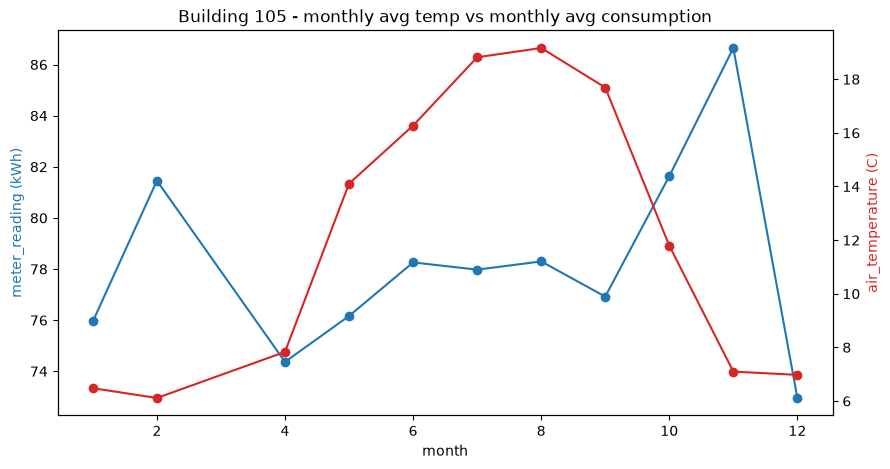

,air_temperature,meter_reading
month,,
1,6.477554,75.953285
2,6.112213,81.456536
4,7.831179,74.369364
5,14.107258,76.164855
6,16.270972,78.260417
7,18.819220,77.976791
8,19.165457,78.299058
9,17.691528,76.923212
10,11.794086,81.635128


In [33]:
df['month'] = df['timestamp'].dt.month
monthly = df.groupby('month')[['air_temperature', 'meter_reading']].mean()

fig, ax1 = plt.subplots(figsize=(10,5))
ax2 = ax1.twinx()
ax1.plot(monthly.index, monthly['meter_reading'], color='tab:blue', marker='o', label='avg meter_reading')
ax2.plot(monthly.index, monthly['air_temperature'], color='tab:red', marker='o', label='avg air_temperature')
ax1.set_xlabel('month'); ax1.set_ylabel('meter_reading (kWh)', color='tab:blue')
ax2.set_ylabel('air_temperature (C)', color='tab:red')
ax1.set_title('Building 105 - monthly avg temp vs monthly avg consumption')
plt.show()

monthly

Consumption does not closely follow temperature. This suggests building usage or the academic calendar may have a stronger effect.

### Feature Engineering

required calendar features (`hour`, `dow`, `month`) are already on `df` from earlier steps. adding the two lag features next: previous-day (`lag_24h`) and previous-week (`lag_168h`) same-hour reading - the ACF plot in Step 2 showed both cycles are real, with the weekly one actually the stronger predictor

lags are built by looking up `meter_reading` at `timestamp - 24h` / `timestamp - 168h` rather than a plain `.shift(24)`. that matters here specifically because the dead-flat stretch was dropped in Step 3 - `df` isn't perfectly hourly-continuous anymore, so a row-position shift would silently pull a reading from *before* the gap and mislabel it as "24 hours ago" once the data resumes after the gap. the timestamp lookup correctly returns NaN instead when the true prior timestamp doesn't exist in the data.

In [34]:
lookup = df.set_index('timestamp')['meter_reading']

df['lag_24h']  = (df['timestamp'] - pd.Timedelta(hours=24)).map(lookup)
df['lag_168h'] = (df['timestamp'] - pd.Timedelta(hours=168)).map(lookup)

df[['timestamp', 'meter_reading', 'lag_24h', 'lag_168h']].head(10)

,timestamp,meter_reading,lag_24h,lag_168h
0,2016-01-01 00:00:00,23.3036,NaN,NaN
1,2016-01-01 01:00:00,45.6071,NaN,NaN
2,2016-01-01 02:00:00,45.6071,NaN,NaN
3,2016-01-01 03:00:00,45.1071,NaN,NaN
4,2016-01-01 04:00:00,45.6071,NaN,NaN
5,2016-01-01 05:00:00,45.1071,NaN,NaN
6,2016-01-01 06:00:00,45.1071,NaN,NaN
7,2016-01-01 07:00:00,43.6071,NaN,NaN
8,2016-01-01 08:00:00,46.1071,NaN,NaN
9,2016-01-01 09:00:00,47.6071,NaN,NaN


In [35]:
df[['lag_24h', 'lag_168h']].isna().sum()

lag_24h      48
lag_168h    336
dtype: int64

NaN counts: 48 missing for `lag_24h` (first day of data + first day after the gap), 336 for `lag_168h` (first week of data + first week after the gap).

dropping rows without a full lag history before modeling (336 rows) (~4.4% of the post-gap data), which is okay because we get two informative lag features, and ~7,200 rows remain.

In [36]:
df_model = df.dropna(subset=['lag_24h', 'lag_168h']).reset_index(drop=True)
print('before:', df.shape, ' after dropping incomplete lag history:', df_model.shape)
df_model[['timestamp', 'meter_reading', 'hour', 'dow', 'month', 'lag_24h', 'lag_168h']].head()

before: (7583, 14)  after dropping incomplete lag history: (7247, 14)


,timestamp,meter_reading,hour,dow,month,lag_24h,lag_168h
0,2016-01-08 00:00:00,78.2523,0,4,1,78.2523,23.3036
1,2016-01-08 01:00:00,78.2523,1,4,1,78.2523,45.6071
2,2016-01-08 02:00:00,78.2523,2,4,1,78.2523,45.6071
3,2016-01-08 03:00:00,78.2523,3,4,1,78.2523,45.1071
4,2016-01-08 04:00:00,78.2523,4,4,1,78.2523,45.6071


### Model Selection

| Model | Reason |
|---|---|
| Linear Regression | Assumes straight-line relationships; misses interaction effects between hour, day, and consumption patterns |
| ARIMA | Built for single series; can't easily incorporate external features like hour, dow, lags |
| Random Forest | Works, but usually needs more trees/tuning to match XGBoost's accuracy, and is slower to train |
| XGBoost | ✓ Chosen — handles nonlinearity, uses all features natively, no scaling needed |

### Justification

Went with XGBoost because the relationship between features (hour, dow, month, lag_24h, lag_168h) and meter_reading isn't linear — usage jumps around depending on combinations like hour + weekday. XGBoost picks up on these patterns and interactions on its own.

Also doesn't need feature scaling and isn't thrown off by the odd spikes/flat stretches in the data. It's a standard choice for tabular regression, so it's easy to defend.

In [37]:
df_model.head()

,timestamp,meter_reading,hour,dow,is_weekend,air_temperature,dew_temperature,sea_level_pressure,wind_direction,wind_speed,occupied,month,lag_24h,lag_168h
0,2016-01-08 00:00:00,78.2523,0,4,False,3.3,0.9,1000.3,220.0,4.6,False,1,78.2523,23.3036
1,2016-01-08 01:00:00,78.2523,1,4,False,3.2,1.1,1000.4,220.0,4.6,False,1,78.2523,45.6071
2,2016-01-08 02:00:00,78.2523,2,4,False,2.6,1.0,1000.8,220.0,3.1,False,1,78.2523,45.6071
3,2016-01-08 03:00:00,78.2523,3,4,False,2.7,1.2,1000.9,200.0,3.1,False,1,78.2523,45.1071
4,2016-01-08 04:00:00,78.2523,4,4,False,1.9,0.8,1001.0,220.0,2.1,False,1,78.2523,45.6071


Splitting the data chronologically - first 80% for training, last 20% for testing

In [38]:
#splitting the data
features = ['hour', 'dow', 'month', 'lag_24h', 'lag_168h']
target = 'meter_reading'

split_point = int(len(df_model) * 0.8)

train_df = df_model.iloc[:split_point]
test_df = df_model.iloc[split_point:]

X_train, y_train = train_df[features], train_df[target]
X_test, y_test = test_df[features], test_df[target]

print('train size:', X_train.shape)
print('test size:', X_test.shape)

train size: (5797, 5)
test size: (1450, 5)


Training a basic XGBoost regressor

In [39]:
from xgboost import XGBRegressor

model = XGBRegressor(random_state = 42)

model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


Saving the trained model to a file so it can be loaded later (e.g. by a serving script on GCP) without retraining. `../models` sits in the parent directory, one level up from this notebook, and is created if it does not already exist.

In [40]:
import os
import joblib

os.makedirs('../models', exist_ok=True)
joblib.dump(model, '../models/model.pkl')
print('Model saved to ../models/model.pkl')

Model saved to ../models/model.pkl


In [41]:
predictions = model.predict(X_test)
predictions[:10]

array([149.08662 , 144.48581 , 144.73221 , 139.54524 , 119.83082 ,
       101.280365,  90.98355 ,  86.773705,  74.5785  ,  65.119705],
      dtype=float32)

In [42]:
y_test[:10]

5797    147.5780
5798    147.2970
5799    150.2970
5800    147.4060
5801    128.1250
5802    108.8120
5803     92.9845
5804     79.5235
5805     67.9920
5806     64.0625
Name: meter_reading, dtype: float64

Plotting predicted vs actual meter readings on the test set to see how well the model tracks the real pattern.

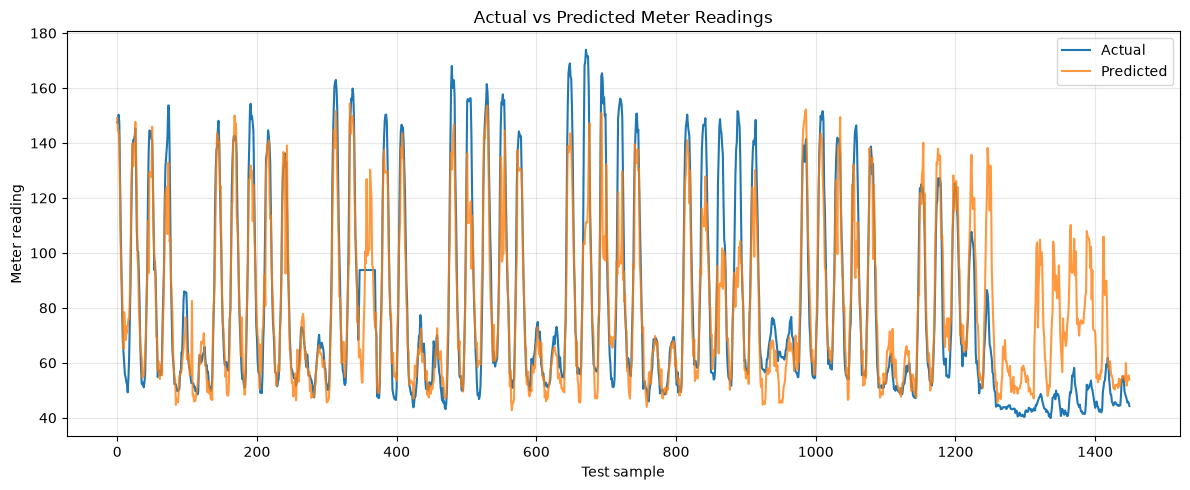

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(y_test.to_numpy(), label='Actual', linewidth=1.5)
plt.plot(predictions, label='Predicted', linewidth=1.5, alpha=0.8)
plt.xlabel('Test sample')
plt.ylabel('Meter reading')
plt.title('Actual vs Predicted Meter Readings')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Evaluating the model using RMSE and MAE, and comparing predicted vs actual values on the test set.

In [44]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse = (mean_squared_error(y_test, predictions))**0.5
rmse

17.3108162980217

In [45]:
mae = (mean_absolute_error(y_test, predictions))
mae

11.231880555950298

RMSE: 17.3, MAE: 11.2. RMSE being noticeably higher than MAE suggests a few large misses are pulling the error up, likely from the shift in actual readings seen late in the test period.

Plotting residuals (predicted - actual) over the test period to see exactly where and how much the model is off.

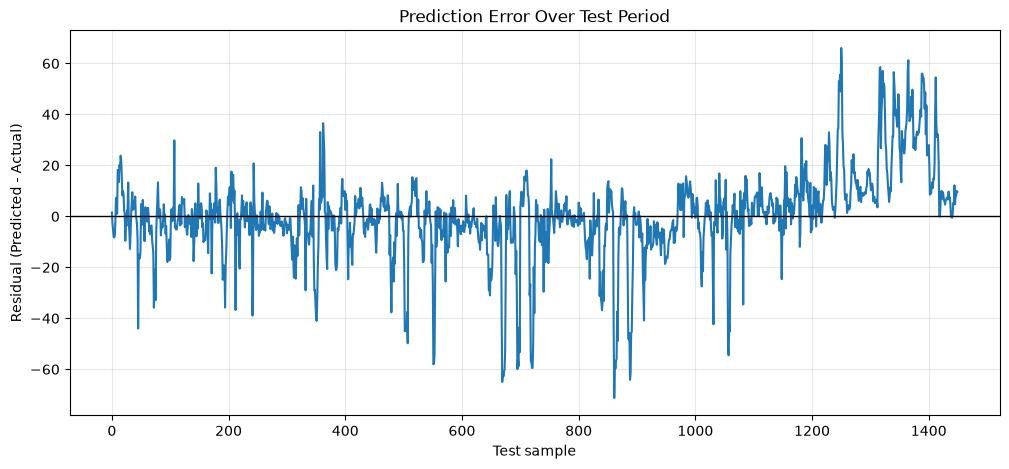

In [46]:
residuals = predictions - y_test.to_numpy()

plt.figure(figsize=(12, 5))
plt.plot(residuals)
plt.axhline(0, color='black', linewidth=1)
plt.xlabel('Test sample')
plt.ylabel('Residual (Predicted - Actual)')
plt.title('Prediction Error Over Test Period')
plt.grid(alpha=0.3)
plt.show()

Checking what real-world date the residual shift (~sample 1250) corresponds to.

In [47]:
test_df['timestamp'].iloc[1250]

Timestamp('2016-12-23 16:00:00')

The residual shift starting ~sample 1250 lines up with 2016-12-23 - the start of winter break. Building 105 is an Education building, so occupancy (and consumption) drops sharply once the semester ends. The model, trained mostly on regular semester patterns, doesn't know a holiday shutdown is coming and keeps predicting normal usage - explains the sustained over-prediction late in the test period.

Checking feature importance to see which features the model is relying on most.

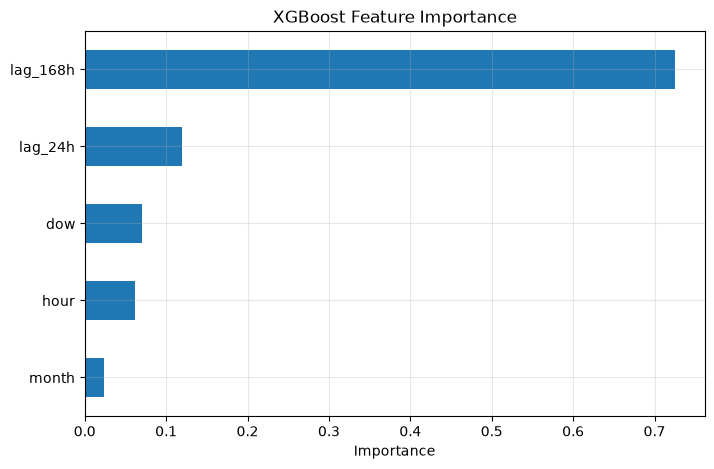

In [48]:
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh')
plt.xlabel('Importance')
plt.title('XGBoost Feature Importance')
plt.gca().invert_yaxis()
plt.grid(alpha=0.3)
plt.show()

lag_168h dominates (~72% importance), with lag_24h a distant second (~12%). hour, dow, and month together barely matter (~16% combined) - the model is mostly relying on "same hour last week" as its main signal. This explains the holiday failure: once the actual pattern shifts, last week's value stops being a reliable predictor, and the model has no other strong feature to fall back on.

Baseline model - just predict the same hour from the previous week (lag_168h) as the forecast, and compare against XGBoost.

In [49]:
baseline_preds = test_df['lag_168h']

baseline_rmse = (mean_squared_error(y_test, baseline_preds))**0.5
baseline_mae = mean_absolute_error(y_test, baseline_preds)

print('baseline RMSE:', baseline_rmse, ' baseline MAE:', baseline_mae)
print('xgboost RMSE:', rmse, ' xgboost MAE:', mae)

baseline RMSE: 16.832122838567763  baseline MAE: 10.392671862068966
xgboost RMSE: 17.3108162980217  xgboost MAE: 11.231880555950298


Baseline RMSE: 16.8, MAE: 10.4 vs XGBoost RMSE: 17.3, MAE: 11.2 - XGBoost did not beat the baseline. Given lag_168h already makes up ~72% of the model's feature importance, XGBoost is mostly reproducing the baseline plus some noise from the other features and default hyperparameters. With more time I'd try predicting the difference from last week instead of the raw value, tune the model settings so it doesn't overfit noise, and add a flag marking holiday periods so it can catch the winter break shift.